---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>

---

## Instalação das dependências

Execute esta célula antes de qualquer outra para garantir que todas as bibliotecas estejam disponíveis.

| Biblioteca | Uso |
|------------|-----|
| `numpy` | Manipulação de arrays e álgebra linear |
| `pandas` | Leitura do CSV de regressão |
| `matplotlib` | Visualizações e gráficos |
| `torch` | Tensores, autograd e otimizadores |

In [1]:
%pip install numpy pandas matplotlib torch --quiet

Note: you may need to restart the kernel to use updated packages.


## Aula 03: Fully Connected Neural Networks com PyTorch

Nas aulas anteriores construímos redes neurais **do zero com NumPy**  implementando manualmente cada equação de forward propagation, backpropagation e atualização de pesos. Esse exercício foi fundamental para entender o que acontece "por baixo dos panos".

Agora utilizamos o **PyTorch**: o framework calcula gradientes automaticamente (autograd) e oferece blocos prontos para construir redes, mas **os princípios matemáticos são exatamente os mesmos** que você já domina.

### Roteiro

| Seção | Conteúdo |
|-------|----------|
| **1** | PyTorch vs NumPy manual  correspondência direta |
| **2** | Bibliotecas, imports e funções auxiliares |
| **3** | Caso 1: Regressão com `data/regression_example.csv` |
| **4** | Caso 2: Classificação com dataset sintético (bullseye) |
| **5** | Comparativo final e próximos passos |

### Objetivos de aprendizado

Ao final desta aula, você será capaz de:
- Criar modelos FNN com `torch.nn.Module`
- Entender como o `autograd` substitui o backpropagation manual
- Treinar redes para regressão (MSE) e classificação multiclasse (Cross-Entropy)
- Avaliar modelos com métricas e visualizar a fronteira de decisão
- Conectar cada componente PyTorch ao equivalente implementado na Aula 01

---

## 1. PyTorch vs Implementação Manual

Na Aula 01, cada etapa foi implementada explicitamente. O PyTorch **não elimina essas etapas  ele as automatiza**:

| Componente | Aula 01 (NumPy manual) | Aula 03 (PyTorch) |
|------------|----------------------|-------------------|
| **Pesos** | `params = {"W1": ..., "b1": ...}` | `nn.Linear(in, out)` |
| **Forward** | `ForwardPropagation(X, params)` | `model(X)` |
| **Loss** | `compute_cost(AL, Y)` | `criterion(pred, target)` |
| **Backward** | `BackPropagation(X, Y, params, caches)` | `loss.backward()` |
| **Update** | `params["W1"] -= lr * grads["dW1"]` | `optimizer.step()` |
| **Zerar gradientes** | implícito na reinicialização | `optimizer.zero_grad()` |

### 1.1 O que é o Autograd?

Ao chamar `loss.backward()`, o PyTorch percorre o grafo computacional **em sentido inverso** e calcula $\frac{\partial L}{\partial w}$ para cada parâmetro automaticamente  exatamente o que fazíamos com as equações de backpropagation.

### 1.2 Loop de treinamento padrão

```
para cada época:
    1. optimizer.zero_grad()      # limpa gradientes acumulados
    2. pred = model(X)            # forward pass
    3. loss = criterion(pred, y)  # calcula a perda
    4. loss.backward()            # backward pass (autograd)
    5. optimizer.step()           # atualiza os pesos
```

---

## 2. Bibliotecas e Funções Auxiliares

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}  |  PyTorch {torch.__version__}")

Dispositivo: cpu  |  PyTorch 2.10.0


### 2.1 Normalização Z-score

As mesmas funções da Aula 01  reutilizadas aqui para manter consistência:

$$X_{norm} = \frac{X - \mu}{\sigma + \varepsilon}, \quad \varepsilon = 10^{-8}$$

Estatísticas de normalização são calculadas **apenas com dados de treino** e aplicadas igualmente no teste, evitando *data leakage*.

In [3]:
def normalize_fit(X):
    return X.mean(axis=0), X.std(axis=0)

def normalize_transform(X, media, desvio, eps=1e-8):
    return (X - media) / (desvio + eps)

def normalize_inverse(X_norm, media, desvio, eps=1e-8):
    return X_norm * (desvio + eps) + media

### 2.2 Visualização da Arquitetura

Função que desenha graficamente a FNN: cada coluna é uma camada, cada círculo é um neurônio e as linhas representam as conexões densas.

In [4]:
def visualizar_fnn(camadas, titulos_camadas=None, titulo="Arquitetura da Rede Neural",
                   max_neuronios=8, figsize=(14, 6)):
    """Desenha uma FNN com matplotlib.

    Parâmetros
    ----------
    camadas : list[int]    neurônios por camada, ex: [4, 64, 32, 1]
    max_neuronios : int    círculos máximos por camada (camadas largas são truncadas)
    """
    import matplotlib.patches as mpatches

    n = len(camadas)
    if titulos_camadas is None:
        titulos_camadas = ["Entrada"] + [f"Oculta {i}" for i in range(1, n-1)] + ["Saída"]

    def cor(idx):
        if idx == 0:     return "#42A5F5"
        if idx == n - 1: return "#EF5350"
        return "#66BB6A"

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.38, 1.08)
    ax.axis("off")
    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=14)

    posicoes = []
    for k in camadas:
        n_vis = min(k, max_neuronios)
        trunc = k > max_neuronios
        meio  = max_neuronios // 2
        if trunc:
            slots = n_vis + 1
            ys_n  = list(range(meio)) + list(range(meio + 1, n_vis + 1))
            ys_r  = [meio]
        else:
            slots = max(n_vis, 1)
            ys_n  = list(range(n_vis))
            ys_r  = []
        f = lambda y, s=slots: y / max(s - 1, 1)
        posicoes.append({"n": [f(y) for y in ys_n], "r": [f(y) for y in ys_r], "total": k})

    r = 0.028
    for l in range(n - 1):
        for ya in posicoes[l]["n"]:
            for yb in posicoes[l+1]["n"]:
                ax.plot([l, l+1], [ya, yb], color="#BDBDBD", lw=0.35, alpha=0.5, zorder=1)

    for l, info in enumerate(posicoes):
        for y in info["n"]:
            ax.add_patch(plt.Circle((l, y), r, color=cor(l), ec="white", lw=1.2,
                                    zorder=3, clip_on=False))
        for y in info["r"]:
            ax.text(l, y, "\u22ee", ha="center", va="center",
                    fontsize=14, color="#757575", zorder=4)
        ax.text(l, -0.13, titulos_camadas[l], ha="center", va="top",
                fontsize=9.5, color="#212121", fontweight="bold")
        ax.text(l, -0.23, f"({info['total']} neur.)", ha="center", va="top",
                fontsize=8, color="#757575")

    legenda = [
        mpatches.Patch(color="#42A5F5", label="Entrada"),
        mpatches.Patch(color="#66BB6A", label="Oculta (ReLU)"),
        mpatches.Patch(color="#EF5350", label="Saída"),
    ]
    ax.legend(handles=legenda, loc="upper right", fontsize=9,
              framealpha=0.85, edgecolor="#E0E0E0")
    plt.tight_layout()
    plt.show()

---

## 3. Caso 1: Regressão

### 3.1 Objetivo

Treinar uma FNN para prever um valor contínuo (`target`) a partir de **4 features numéricas**, usando o dataset `data/regression_example.csv`  o mesmo utilizado na Aula 01.

### 3.2 Dataset

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `feature1` … `feature4` | numérico | Variáveis preditoras |
| `target` | numérico | Variável alvo (valor contínuo) |

In [5]:
df = pd.read_csv("data/regression_example.csv")

print(f"Shape  : {df.shape}  ({df.shape[0]} amostras, {df.shape[1]} colunas)")
print(f"Colunas: {list(df.columns)}")
print()
print(df.head())
print()
print("Estatísticas do target:")
print(df['target'].describe().round(3))

X_reg = df.drop(columns=['target']).values   # (400, 4)
y_reg = df['target'].values                  # (400,)

Shape  : (400, 5)  (400 amostras, 5 colunas)
Colunas: ['feature1', 'feature2', 'feature3', 'feature4', 'target']

   feature1  feature2  feature3  feature4     target
0  6.394268  0.250108  2.750293  2.232107  13.476965
1  8.921796  0.869388  4.219218  0.297972  11.877647
2  2.186380  5.053553  0.265360  1.988377  12.316302
3  2.204406  5.892657  8.094305  0.064988  -2.788723
4  8.058193  6.981394  3.402505  1.554795  36.236948

Estatísticas do target:
count    400.000
mean      23.336
std       13.370
min       -9.328
25%       13.825
50%       22.714
75%       32.523
max       57.383
Name: target, dtype: float64


### 3.3 Análise Exploratória

Visualizamos a relação entre cada feature e o target para entender a estrutura dos dados antes de treinar:

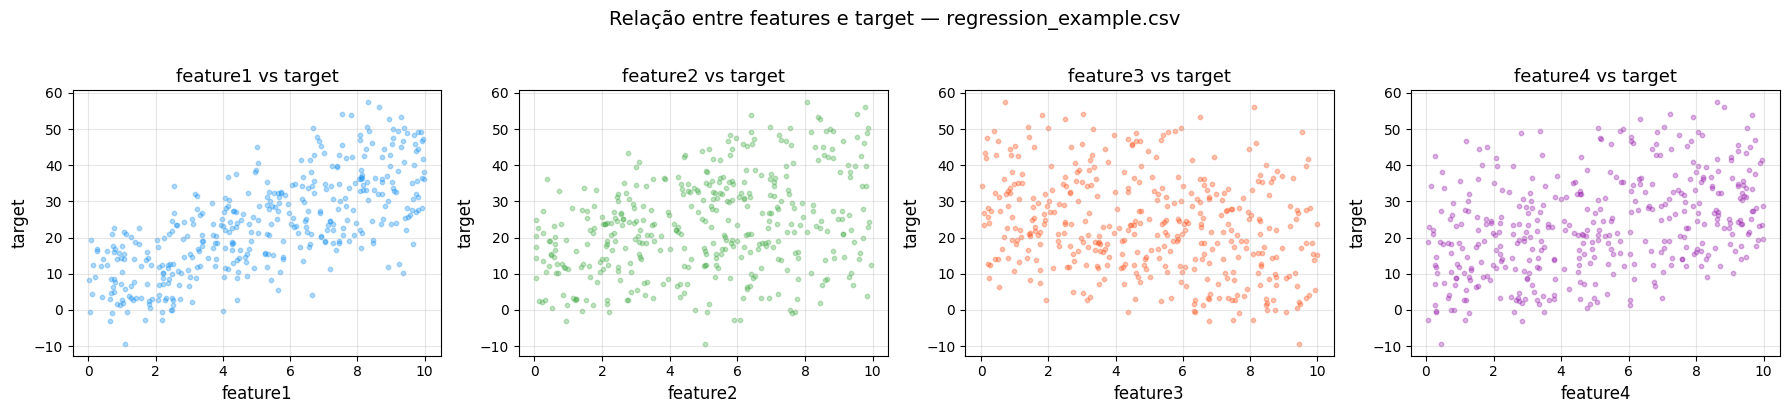

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
nomes_feat = ["feature1", "feature2", "feature3", "feature4"]
cores_feat = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]

for ax, nome, cor in zip(axes, nomes_feat, cores_feat):
    ax.scatter(df[nome], df['target'], alpha=0.35, s=10, color=cor)
    ax.set_xlabel(nome, fontsize=12)
    ax.set_ylabel("target", fontsize=12)
    ax.set_title(f"{nome} vs target", fontsize=13)
    ax.grid(alpha=0.3)

plt.suptitle("Relação entre features e target  regression_example.csv",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Normalização e Preparação dos Tensores

Aplicamos Z-score em **X** e **y** separadamente. O `fit` usa apenas dados de treino para evitar *data leakage*.

In [7]:
# Divisão treino/teste 80/20
n_total  = len(X_reg)
n_treino = int(0.8 * n_total)
idx      = np.random.permutation(n_total)
idx_tr, idx_te = idx[:n_treino], idx[n_treino:]

X_tr_raw, X_te_raw = X_reg[idx_tr], X_reg[idx_te]
y_tr_raw, y_te_raw = y_reg[idx_tr], y_reg[idx_te]

# Normalização (fit apenas no treino)
media_X, desvio_X = normalize_fit(X_tr_raw)
media_y, desvio_y = normalize_fit(y_tr_raw.reshape(-1, 1))

X_tr = normalize_transform(X_tr_raw, media_X, desvio_X)
X_te = normalize_transform(X_te_raw, media_X, desvio_X)
y_tr = normalize_transform(y_tr_raw.reshape(-1, 1), media_y, desvio_y)
y_te = normalize_transform(y_te_raw.reshape(-1, 1), media_y, desvio_y)

# Tensores
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
y_te_t = torch.tensor(y_te, dtype=torch.float32).to(device)

# DataLoader com mini-batches de 32
loader_tr = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

print(f"Treino : {X_tr_t.shape[0]} amostras")
print(f"Teste  : {X_te_t.shape[0]} amostras")
print(f"Batches por época: {len(loader_tr)}")

Treino : 320 amostras
Teste  : 80 amostras
Batches por época: 10


### 3.5 Definição do Modelo

Toda rede no PyTorch é uma **classe** que herda de `nn.Module`. O método `forward` descreve o fluxo dos dados.

Arquitetura:

$$
\mathbb{R}^4 \xrightarrow{\text{Linear}} \mathbb{R}^{64} \xrightarrow{\text{ReLU}} \mathbb{R}^{32} \xrightarrow{\text{ReLU}} \mathbb{R}^{16} \xrightarrow{\text{ReLU}} \mathbb{R}^1
$$

A camada de saída **não tem ativação**  produz diretamente o valor contínuo.

In [8]:
class RegressaoFNN(nn.Module):
    """FNN para regressão. Arquitetura: 4 -> 64 -> 32 -> 16 -> 1"""

    def __init__(self):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(4, 64),  nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.rede(x)


modelo_reg = RegressaoFNN().to(device)
print(modelo_reg)
n_params = sum(p.numel() for p in modelo_reg.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_params:,}")

RegressaoFNN(
  (rede): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

Parâmetros treináveis: 2,945


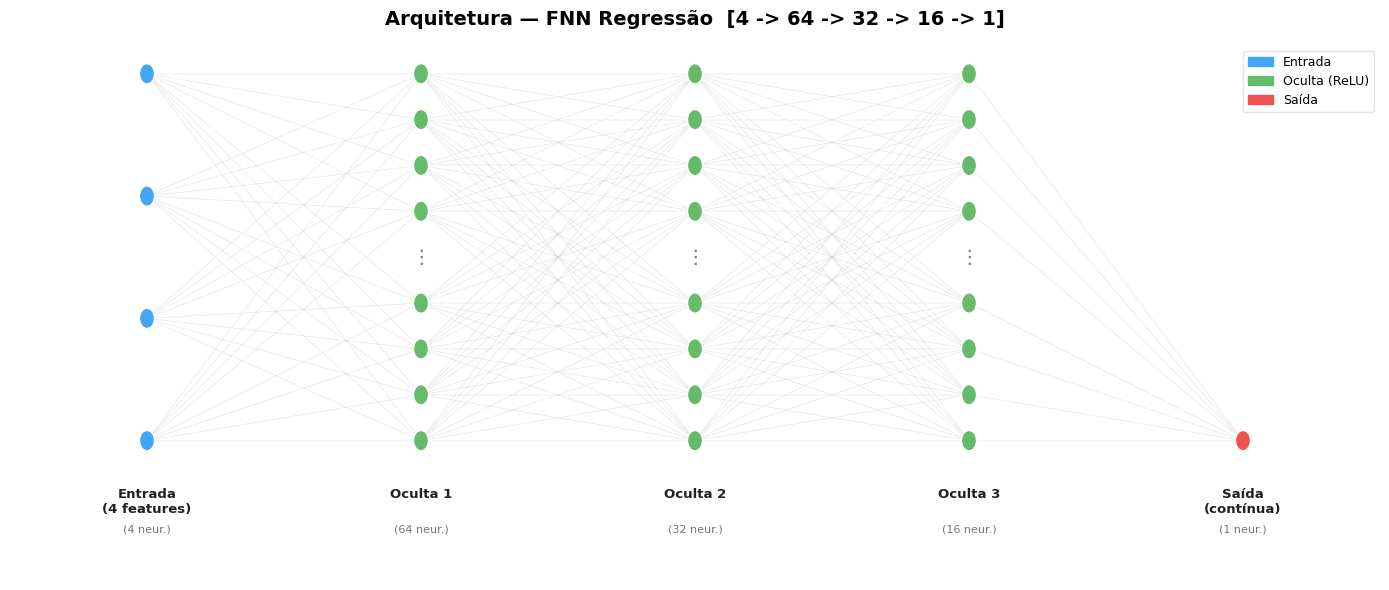

In [9]:
visualizar_fnn(
    camadas=[4, 64, 32, 16, 1],
    titulos_camadas=["Entrada\n(4 features)", "Oculta 1", "Oculta 2", "Oculta 3",
                     "Saída\n(contínua)"],
    titulo="Arquitetura  FNN Regressão  [4 -> 64 -> 32 -> 16 -> 1]",
)

### 3.6 Função de Perda e Otimizador

Para regressão, usamos o **Erro Quadrático Médio** (MSE):

$$\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

Como otimizador, utilizamos **Adam**  estende o gradiente descendente adaptando a taxa de aprendizado por parâmetro:

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon} \cdot \hat{m}_t$$

In [10]:
criterio_reg   = nn.MSELoss()
otimizador_reg = optim.Adam(modelo_reg.parameters(), lr=0.005)
epocas_reg     = 2000

hist_tr_reg, hist_te_reg = [], []

for epoca in range(1, epocas_reg + 1):

    modelo_reg.train()
    loss_tr = 0.0
    for X_b, y_b in loader_tr:
        otimizador_reg.zero_grad()
        loss = criterio_reg(modelo_reg(X_b), y_b)
        loss.backward()
        otimizador_reg.step()
        loss_tr += loss.item()
    loss_tr /= len(loader_tr)

    modelo_reg.eval()
    with torch.no_grad():
        loss_te = criterio_reg(modelo_reg(X_te_t), y_te_t).item()

    hist_tr_reg.append(loss_tr)
    hist_te_reg.append(loss_te)

    if epoca % 200 == 0 or epoca == 1:
        print(f"Época {epoca:>4} | Loss Treino: {loss_tr:.5f} | Loss Teste: {loss_te:.5f}")

print("\nTreinamento concluído!")

Época    1 | Loss Treino: 0.69486 | Loss Teste: 0.29134
Época  200 | Loss Treino: 0.00852 | Loss Teste: 0.05419
Época  400 | Loss Treino: 0.00349 | Loss Teste: 0.04589
Época  600 | Loss Treino: 0.00097 | Loss Teste: 0.04962
Época  800 | Loss Treino: 0.00060 | Loss Teste: 0.05070
Época 1000 | Loss Treino: 0.00047 | Loss Teste: 0.05094
Época 1200 | Loss Treino: 0.00088 | Loss Teste: 0.05119
Época 1400 | Loss Treino: 0.00051 | Loss Teste: 0.05040
Época 1600 | Loss Treino: 0.00013 | Loss Teste: 0.04840
Época 1800 | Loss Treino: 0.00112 | Loss Teste: 0.05022
Época 2000 | Loss Treino: 0.00147 | Loss Teste: 0.05102

Treinamento concluído!


### 3.7 Avaliação e Visualização dos Resultados

RMSE (escala original): 3.0040
MAE  (escala original): 2.3447


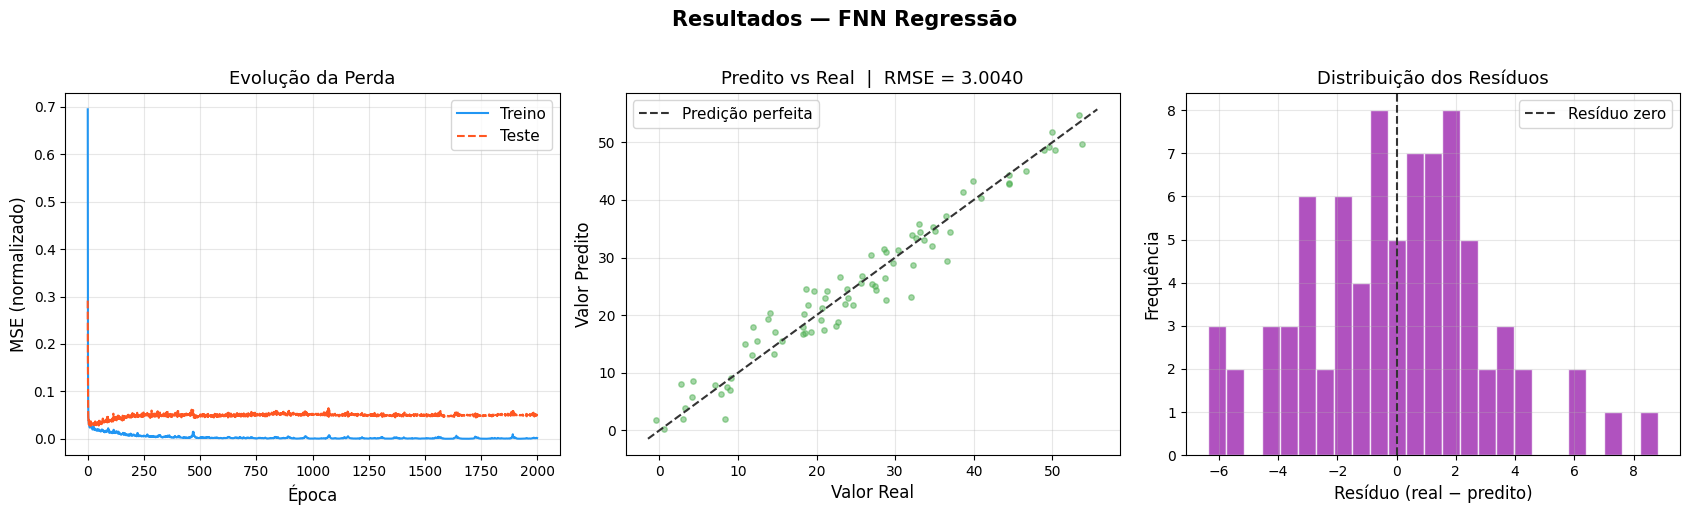

In [11]:
# Predições revertidas para a escala original
modelo_reg.eval()
with torch.no_grad():
    pred_norm = modelo_reg(X_te_t).cpu().numpy()

pred_orig = normalize_inverse(pred_norm, media_y, desvio_y).flatten()
real_orig = y_te_raw
residuos  = real_orig - pred_orig

rmse = np.sqrt(np.mean(residuos**2))
mae  = np.mean(np.abs(residuos))
print(f"RMSE (escala original): {rmse:.4f}")
print(f"MAE  (escala original): {mae:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Painel 1  Curva de perda
ax = axes[0]
ax.plot(hist_tr_reg, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_te_reg, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("MSE (normalizado)", fontsize=12)
ax.set_title("Evolução da Perda", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Painel 2  Predito vs Real
ax = axes[1]
ax.scatter(real_orig, pred_orig, alpha=0.5, s=15, color="#4CAF50")
lim = [min(real_orig.min(), pred_orig.min()) - 1,
       max(real_orig.max(), pred_orig.max()) + 1]
ax.plot(lim, lim, "--", color="#333", lw=1.5, label="Predição perfeita")
ax.set_xlabel("Valor Real", fontsize=12)
ax.set_ylabel("Valor Predito", fontsize=12)
ax.set_title(f"Predito vs Real  |  RMSE = {rmse:.4f}", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Painel 3  Resíduos
ax = axes[2]
ax.hist(residuos, bins=25, color="#9C27B0", edgecolor="white", alpha=0.8)
ax.axvline(0, color="#333", lw=1.5, linestyle="--", label="Resíduo zero")
ax.set_xlabel("Resíduo (real − predito)", fontsize=12)
ax.set_ylabel("Frequência", fontsize=12)
ax.set_title("Distribuição dos Resíduos", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.suptitle("Resultados  FNN Regressão", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.8 Interpretação dos Resultados

| Gráfico | O que observar |
|---------|---------------|
| **Curva de perda** | Treino e teste convergindo próximos. Gap grande indica *overfitting*. |
| **Predito vs Real** | Pontos concentrados na reta $y = x$ indicam boa predição. |
| **Resíduos** | Distribuição normal centrada em zero → erros aleatórios, sem viés. |

---

## 4. Caso 2: Classificação

### 4.1 Objetivo

Treinar uma FNN para **classificar pontos 2D em 3 classes** com fronteira de decisão circular  um problema impossível para qualquer classificador linear.

### 4.2 Estrutura do Dataset

O dataset **bullseye** atribui classes pela distância à origem $r = \sqrt{x_1^2 + x_2^2}$:

| Classe | Região | Condição |
|--------|--------|----------|
| **0** | Disco central | $r < 1.8$ |
| **1** | Anel intermediário | $1.8 \leq r < 3.5$ |
| **2** | Anel externo | $r \geq 3.5$ |

A fronteira é **circular**  a FNN precisa aprender implicitamente a calcular o raio a partir de $x_1$ e $x_2$.

In [12]:
def criar_dataset_bullseye(n=1500, seed=42):
    """Gera pontos 2D uniformes e classifica pela distância à origem."""
    rng = np.random.default_rng(seed)

    X_pool = rng.uniform(-5.5, 5.5, size=(n * 6, 2))
    r      = np.sqrt(X_pool[:, 0]**2 + X_pool[:, 1]**2)
    y_pool = np.where(r < 1.8, 0, np.where(r < 3.5, 1, 2))

    # Balanceia as 3 classes
    n_por_classe = n // 3
    X_parts, y_parts = [], []
    for k in range(3):
        idx_k = np.where(y_pool == k)[0]
        escolhidos = rng.choice(idx_k, size=n_por_classe, replace=False)
        X_parts.append(X_pool[escolhidos])
        y_parts.append(y_pool[escolhidos])

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]


X_clf, y_clf = criar_dataset_bullseye(n=1500)
print(f"Shape: {X_clf.shape}")
print(f"Distribuição: { {k: int((y_clf == k).sum()) for k in [0, 1, 2]} }")

Shape: (1500, 2)
Distribuição: {0: 500, 1: 500, 2: 500}


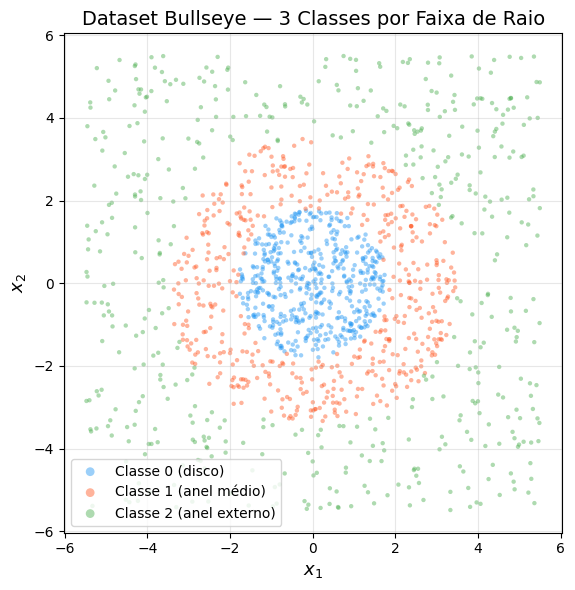

In [13]:
cores_clf = ["#2196F3", "#FF5722", "#4CAF50"]
nomes_clf = ["Classe 0 (disco)", "Classe 1 (anel médio)", "Classe 2 (anel externo)"]

fig, ax = plt.subplots(figsize=(7, 6))
for k, (cor, nome) in enumerate(zip(cores_clf, nomes_clf)):
    mask = y_clf == k
    ax.scatter(X_clf[mask, 0], X_clf[mask, 1],
               c=cor, label=nome, alpha=0.45, s=10, edgecolors="none")
ax.set_xlabel(r"$x_1$", fontsize=13)
ax.set_ylabel(r"$x_2$", fontsize=13)
ax.set_title("Dataset Bullseye  3 Classes por Faixa de Raio", fontsize=14)
ax.legend(fontsize=10, markerscale=2)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Preparação dos Dados

In [14]:
# Divisão treino/teste 80/20
n_clf    = len(X_clf)
idx_clf  = np.random.permutation(n_clf)
n_tr_clf = int(0.8 * n_clf)
idx_tr_c, idx_te_c = idx_clf[:n_tr_clf], idx_clf[n_tr_clf:]

X_tr_c, X_te_c = X_clf[idx_tr_c], X_clf[idx_te_c]
y_tr_c, y_te_c = y_clf[idx_tr_c], y_clf[idx_te_c]

# Normalização
media_Xc, desvio_Xc = normalize_fit(X_tr_c)
X_tr_cn = normalize_transform(X_tr_c, media_Xc, desvio_Xc)
X_te_cn = normalize_transform(X_te_c, media_Xc, desvio_Xc)

# Tensores (y deve ser Long para CrossEntropyLoss)
X_tr_ct = torch.tensor(X_tr_cn, dtype=torch.float32).to(device)
y_tr_ct = torch.tensor(y_tr_c,  dtype=torch.long).to(device)
X_te_ct = torch.tensor(X_te_cn, dtype=torch.float32).to(device)
y_te_ct = torch.tensor(y_te_c,  dtype=torch.long).to(device)

loader_tr_c = DataLoader(TensorDataset(X_tr_ct, y_tr_ct), batch_size=32, shuffle=True)
print(f"Treino: {X_tr_ct.shape[0]} | Teste: {X_te_ct.shape[0]}")

Treino: 1200 | Teste: 300


### 4.4 Definição do Modelo

#### O que são logits?

**Logits** são os valores brutos que a rede produz na última camada, antes de qualquer transformação em probabilidade.
Para cada entrada $x$, a rede calcula:

$$\mathbf{z} = W \cdot h + b \quad \in \mathbb{R}^K$$

onde $K$ é o número de classes. Esses valores não têm restrição de intervalo nem somam 1  são pontuações brutas.
Só após o **softmax** eles se tornam probabilidades:

$$p_k = \frac{e^{z_k}}{\sum_j e^{z_j}} \in (0, 1), \qquad \sum_k p_k = 1$$

**Exemplo com 3 classes:**

| Classe | Logit $z_k$ | Após softmax $p_k$ |
|--------|------------|--------------------|
| 0 | 2.1 | 0.67 |
| 1 | 0.8 | 0.19 |
| 2 | 0.3 | 0.12 |

A classe predita é sempre a de **maior logit**, que coincide com a de maior probabilidade  por isso `argmax(logits) == argmax(probs)` e não precisamos do softmax para classificar.

---

#### Por que a saída da rede é linear (sem ativação)?

Não aplicamos nenhuma ativação na última camada porque não queremos restringir os logits a um intervalo fixo. A rede deve ser livre para atribuir qualquer pontuação a cada classe  a `CrossEntropyLoss` se encarrega do resto.

---

#### Por que usamos `nn.CrossEntropyLoss`?

A `CrossEntropyLoss` do PyTorch combina **três operações em uma**:

$$\text{CrossEntropyLoss}(\mathbf{z},\, y) = -\log\frac{e^{z_y}}{\sum_k e^{z_k}} = \underbrace{-\log\,\text{softmax}(\mathbf{z})_y}_{\text{LogSoftmax + NLLLoss}}$$

| Etapa | O que faz |
|-------|-----------|
| **Softmax** | Converte logits em probabilidades: $p_k = e^{z_k} / \sum_j e^{z_j}$ |
| **Log** | Aplica logaritmo  penaliza mais quando a probabilidade da classe correta está baixa |
| **NLLLoss** | Retorna $-\log(p_y)$: quanto menor a probabilidade prevista para a classe correta, maior a perda |

Como o softmax já está **embutido na loss**, aplicá-lo também no `forward` significaria aplicá-lo duas vezes  distorcendo os gradientes e prejudicando o treino.

Na inferência, para obter probabilidades, aplique o softmax manualmente:

```python
probs = torch.softmax(modelo_clf(X), dim=1)
```

---

#### Arquitetura

$$\mathbb{R}^2 \xrightarrow{\text{Linear}} \mathbb{R}^{128} \xrightarrow{\text{ReLU}} \mathbb{R}^{64} \xrightarrow{\text{ReLU}} \mathbb{R}^{32} \xrightarrow{\text{ReLU}} \mathbb{R}^3 \text{ (logits)}$$

In [15]:
class ClassificacaoFNN(nn.Module):
    """FNN para classificação multiclasse. Arquitetura: 2 -> 128 -> 64 -> 32 -> 3"""

    def __init__(self, n_features=2, n_classes=3):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(n_features, 128), nn.ReLU(),
            nn.Linear(128, 64),         nn.ReLU(),
            nn.Linear(64, 32),          nn.ReLU(),
            nn.Linear(32, n_classes),             # logits  sem softmax
        )

    def forward(self, x):
        return self.rede(x)


modelo_clf = ClassificacaoFNN().to(device)
print(modelo_clf)
n_params_c = sum(p.numel() for p in modelo_clf.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_params_c:,}")

ClassificacaoFNN(
  (rede): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)

Parâmetros treináveis: 10,819


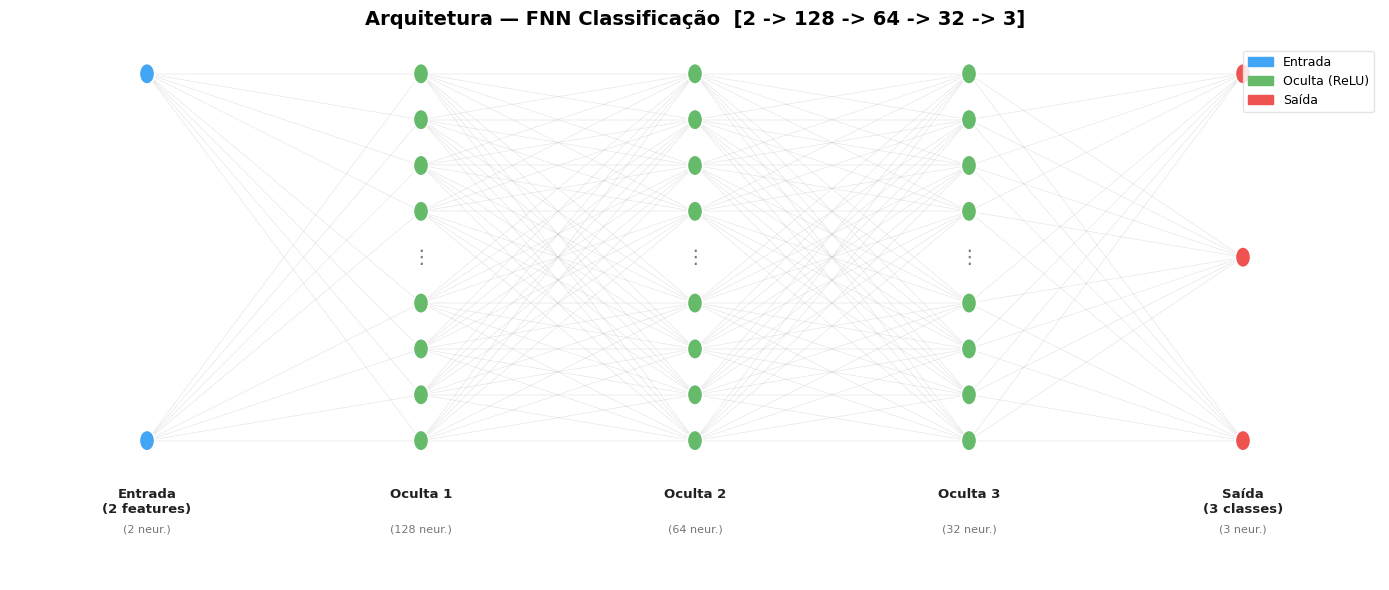

In [16]:
visualizar_fnn(
    camadas=[2, 128, 64, 32, 3],
    titulos_camadas=["Entrada\n(2 features)", "Oculta 1", "Oculta 2", "Oculta 3",
                     "Saída\n(3 classes)"],
    titulo="Arquitetura  FNN Classificação  [2 -> 128 -> 64 -> 32 -> 3]",
)

### 4.5 Treinamento do Classificador

In [17]:
criterio_clf   = nn.CrossEntropyLoss()
otimizador_clf = optim.Adam(modelo_clf.parameters(), lr=0.005)
epocas_clf     = 3000

hist_loss_tr_c, hist_loss_te_c = [], []
hist_acc_tr_c,  hist_acc_te_c  = [], []

def acuracia(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


for epoca in range(1, epocas_clf + 1):

    modelo_clf.train()
    loss_tr, acc_tr = 0.0, 0.0
    for X_b, y_b in loader_tr_c:
        otimizador_clf.zero_grad()
        logits = modelo_clf(X_b)
        loss   = criterio_clf(logits, y_b)
        loss.backward()
        otimizador_clf.step()
        loss_tr += loss.item()
        acc_tr  += acuracia(logits, y_b)
    loss_tr /= len(loader_tr_c)
    acc_tr  /= len(loader_tr_c)

    modelo_clf.eval()
    with torch.no_grad():
        logits_te = modelo_clf(X_te_ct)
        loss_te   = criterio_clf(logits_te, y_te_ct).item()
        acc_te    = acuracia(logits_te, y_te_ct)

    hist_loss_tr_c.append(loss_tr);  hist_loss_te_c.append(loss_te)
    hist_acc_tr_c.append(acc_tr);    hist_acc_te_c.append(acc_te)

    if epoca % 300 == 0 or epoca == 1:
        print(f"Época {epoca:>4} | Loss: {loss_tr:.4f} "
              f"| Acc Treino: {acc_tr:.3f} | Acc Teste: {acc_te:.3f}")

print(f"\nAcurácia final no teste: {hist_acc_te_c[-1]*100:.2f}%")

Época    1 | Loss: 0.6423 | Acc Treino: 0.717 | Acc Teste: 0.907
Época  300 | Loss: 0.0251 | Acc Treino: 0.989 | Acc Teste: 0.987
Época  600 | Loss: 0.0205 | Acc Treino: 0.992 | Acc Teste: 0.977
Época  900 | Loss: 0.0075 | Acc Treino: 0.998 | Acc Teste: 0.980
Época 1200 | Loss: 0.0100 | Acc Treino: 0.998 | Acc Teste: 0.963
Época 1500 | Loss: 0.0201 | Acc Treino: 0.993 | Acc Teste: 0.993
Época 1800 | Loss: 0.0064 | Acc Treino: 0.998 | Acc Teste: 0.980
Época 2100 | Loss: 0.0060 | Acc Treino: 0.997 | Acc Teste: 0.983
Época 2400 | Loss: 0.0922 | Acc Treino: 0.984 | Acc Teste: 0.967
Época 2700 | Loss: 0.0073 | Acc Treino: 0.998 | Acc Teste: 0.980
Época 3000 | Loss: 0.0028 | Acc Treino: 0.999 | Acc Teste: 0.980

Acurácia final no teste: 98.00%


### 4.6 Resultados e Fronteira de Decisão

A **fronteira de decisão** é gerada classificando uma grade densa de pontos e colorindo o mapa com a classe predita:

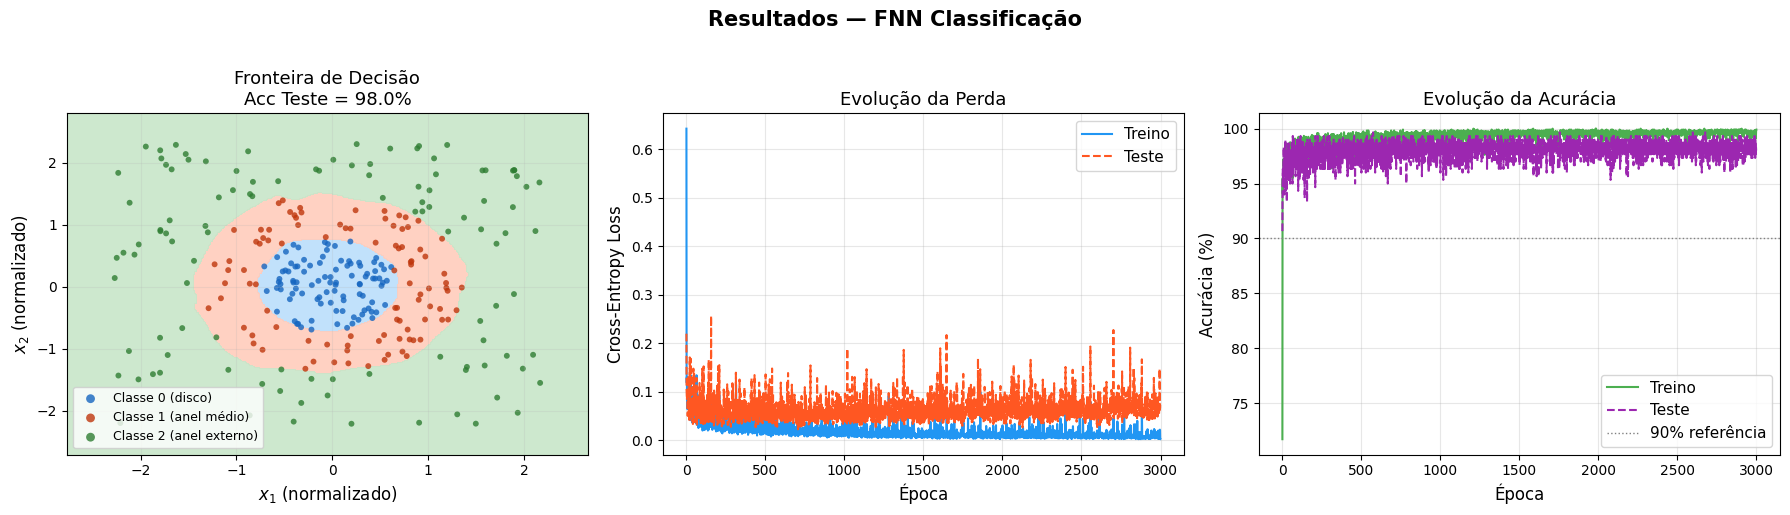

In [18]:
# Grade para fronteira de decisão
res = 300
x1_min, x1_max = X_te_cn[:, 0].min() - 0.5, X_te_cn[:, 0].max() + 0.5
x2_min, x2_max = X_te_cn[:, 1].min() - 0.5, X_te_cn[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, res),
                        np.linspace(x2_min, x2_max, res))
grade_t = torch.tensor(np.column_stack([xx1.ravel(), xx2.ravel()]),
                        dtype=torch.float32).to(device)
modelo_clf.eval()
with torch.no_grad():
    classes_grade = modelo_clf(grade_t).argmax(dim=1).cpu().numpy().reshape(xx1.shape)

paleta_bg  = ["#BBDEFB", "#FFCCBC", "#C8E6C9"]
paleta_pts = ["#1565C0", "#BF360C", "#2E7D32"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Painel 1  Fronteira de decisão
ax = axes[0]
ax.contourf(xx1, xx2, classes_grade, levels=[-0.5, 0.5, 1.5, 2.5],
            colors=paleta_bg, alpha=0.9)
for k, (cor, nome) in enumerate(zip(paleta_pts, nomes_clf)):
    mask = y_te_c == k
    ax.scatter(X_te_cn[mask, 0], X_te_cn[mask, 1],
               c=cor, label=nome, s=18, alpha=0.8, edgecolors="none")
ax.set_xlabel(r"$x_1$ (normalizado)", fontsize=12)
ax.set_ylabel(r"$x_2$ (normalizado)", fontsize=12)
ax.set_title(f"Fronteira de Decisão\nAcc Teste = {hist_acc_te_c[-1]*100:.1f}%", fontsize=13)
ax.legend(fontsize=9, markerscale=1.5)
ax.grid(alpha=0.2)

# Painel 2  Curva de perda
ax = axes[1]
ax.plot(hist_loss_tr_c, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_loss_te_c, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Evolução da Perda", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Painel 3  Curva de acurácia
ax = axes[2]
ax.plot([a * 100 for a in hist_acc_tr_c], label="Treino", color="#4CAF50", lw=1.5)
ax.plot([a * 100 for a in hist_acc_te_c], label="Teste",  color="#9C27B0", lw=1.5, linestyle="--")
ax.axhline(90, color="gray", lw=1, linestyle=":", label="90% referência")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Acurácia (%)", fontsize=12)
ax.set_title("Evolução da Acurácia", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.suptitle("Resultados  FNN Classificação", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.7 Matriz de Confusão

Elementos na **diagonal principal** são acertos; fora dela, erros.

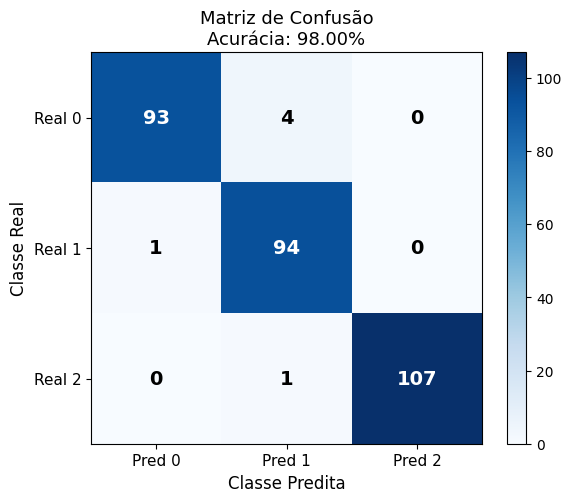

Precisão e Recall por classe:
  Classe 0: Precisão = 0.989 | Recall = 0.959
  Classe 1: Precisão = 0.949 | Recall = 0.989
  Classe 2: Precisão = 1.000 | Recall = 0.991


In [19]:
modelo_clf.eval()
with torch.no_grad():
    pred_te = modelo_clf(X_te_ct).argmax(dim=1).cpu().numpy()

n_classes = 3
matriz = np.zeros((n_classes, n_classes), dtype=int)
np.add.at(matriz, (y_te_c, pred_te), 1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz, cmap="Blues")
plt.colorbar(im, ax=ax)
for i in range(n_classes):
    for j in range(n_classes):
        cor_txt = "white" if matriz[i, j] > matriz.max() * 0.6 else "black"
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center",
                fontsize=14, color=cor_txt, fontweight="bold")
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels([f"Pred {k}" for k in range(n_classes)], fontsize=11)
ax.set_yticklabels([f"Real {k}" for k in range(n_classes)], fontsize=11)
ax.set_xlabel("Classe Predita", fontsize=12)
ax.set_ylabel("Classe Real", fontsize=12)
ax.set_title(f"Matriz de Confusão\nAcurácia: {hist_acc_te_c[-1]*100:.2f}%", fontsize=13)
plt.tight_layout()
plt.show()

print("Precisão e Recall por classe:")
for k in range(n_classes):
    precisao = matriz[k, k] / matriz[:, k].sum() if matriz[:, k].sum() > 0 else 0
    recall   = matriz[k, k] / matriz[k, :].sum() if matriz[k, :].sum() > 0 else 0
    print(f"  Classe {k}: Precisão = {precisao:.3f} | Recall = {recall:.3f}")

---

## 5. Comparativo Final e Próximos Passos

### 5.1 NumPy Manual vs PyTorch

| Aspecto | NumPy Manual (Aulas 0–1) | PyTorch (Aula 3) |
|---------|--------------------------|------------------|
| **Backpropagation** | Equações implementadas à mão | Automático via `loss.backward()` |
| **Velocidade** | Lento para redes grandes | Otimizado, suporta GPU |
| **Clareza pedagógica** | Excelente  cada equação visível | Abstração esconde os detalhes |
| **Uso em produção** | Impraticável para redes profundas | Padrão da indústria |

### 5.2 Recap do Loop de Treinamento

| Passo | O que faz | Por que é necessário |
|-------|-----------|---------------------|
| `zero_grad()` | Zera gradientes acumulados | PyTorch acumula por padrão |
| `model(X)` | Forward pass | Reconstrói o grafo computacional |
| `criterion(pred, y)` | Calcula a perda | Define o sinal de treinamento |
| `loss.backward()` | Calcula $\nabla_{\theta}\mathcal{L}$ | Propaga gradientes pelo grafo |
| `optimizer.step()` | $\theta \leftarrow \theta - \eta \nabla_{\theta}\mathcal{L}$ | Minimiza a perda |

### 5.3 Próximos Passos

| Tópico | O que resolve |
|--------|---------------|
| **Dropout / Weight Decay** | Reduz overfitting |
| **Batch Normalization** | Estabiliza redes muito profundas |
| **Learning Rate Scheduling** | Taxas de aprendizado adaptativas |
| **Redes Convolucionais (CNN)** | Exploram estrutura espacial em imagens |
| **Transformers** | Atenção global  base dos LLMs modernos |

In [20]:
print("=" * 58)
print(" RESUMO  Aula 03: FNN com PyTorch")
print("=" * 58)
print()
print(" CASO 1  REGRESSÃO")
print(f"   Dataset       : data/regression_example.csv (400 amostras)")
print(f"   Arquitetura   : 4 -> 64 -> 32 -> 16 -> 1")
print(f"   Loss final    : {hist_te_reg[-1]:.5f} (MSE normalizado)")
print(f"   RMSE original : {rmse:.4f}")
print(f"   MAE original  : {mae:.4f}")
print()
print(" CASO 2  CLASSIFICAÇÃO")
print(f"   Dataset       : Bullseye sintético (1500 amostras)")
print(f"   Arquitetura   : 2 -> 128 -> 64 -> 32 -> 3")
print(f"   Loss final    : {hist_loss_te_c[-1]:.5f} (Cross-Entropy)")
print(f"   Acurácia teste: {hist_acc_te_c[-1]*100:.2f}%")
print()
print("=" * 58)

 RESUMO  Aula 03: FNN com PyTorch

 CASO 1  REGRESSÃO
   Dataset       : data/regression_example.csv (400 amostras)
   Arquitetura   : 4 -> 64 -> 32 -> 16 -> 1
   Loss final    : 0.05102 (MSE normalizado)
   RMSE original : 3.0040
   MAE original  : 2.3447

 CASO 2  CLASSIFICAÇÃO
   Dataset       : Bullseye sintético (1500 amostras)
   Arquitetura   : 2 -> 128 -> 64 -> 32 -> 3
   Loss final    : 0.07001 (Cross-Entropy)
   Acurácia teste: 98.00%

